<a href="https://colab.research.google.com/github/dhifanhisyam-lang/codefinity-introduction-to-python/blob/master/Dhifan_Hisyam_Alfaridzi_PortfolioPertamaEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Import my necessary Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub


In [9]:
#Upload the dataset
df = pd.read_csv('retail_sales.csv')
df.head()

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [11]:
#Mengubah data type kolom InvoiceDate dari object menjadi datetime64
df['Date'] = pd.to_datetime(df['Date'])

# Cari duplicate, missing value, hapus atau isi dengan data baru

In [13]:
df.describe()

,Date,Sales,Quantity,Profit
count,1825,1823.000000,1820.000000,1825.000000
mean,2023-07-02 00:00:00.000000256,980.482677,10.053846,248.696130
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000
25%,2023-04-02 00:00:00,784.071354,5.000000,156.916498
50%,2023-07-02 00:00:00,997.725134,10.000000,229.344557
75%,2023-10-01 00:00:00,1208.512721,15.000000,324.867847
max,2023-12-31 00:00:00,1888.932537,19.000000,703.228418
std,NaN,336.756618,5.515370,118.159627


(0.0, 180.0)

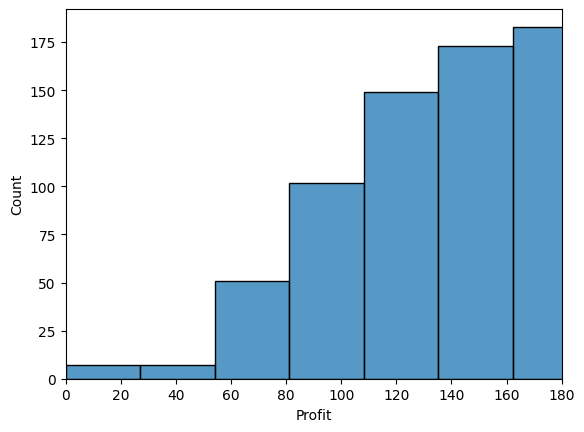

In [19]:
sns.histplot(df['Profit'])
plt.xlim(0,180)

(0.0, 60.0)

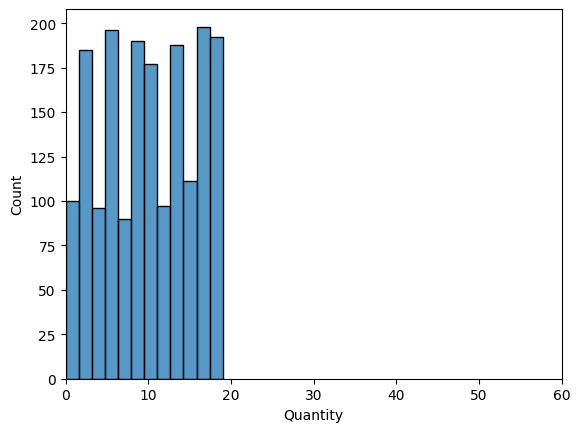

In [21]:
sns.histplot(df['Quantity'])
plt.xlim(0,60)

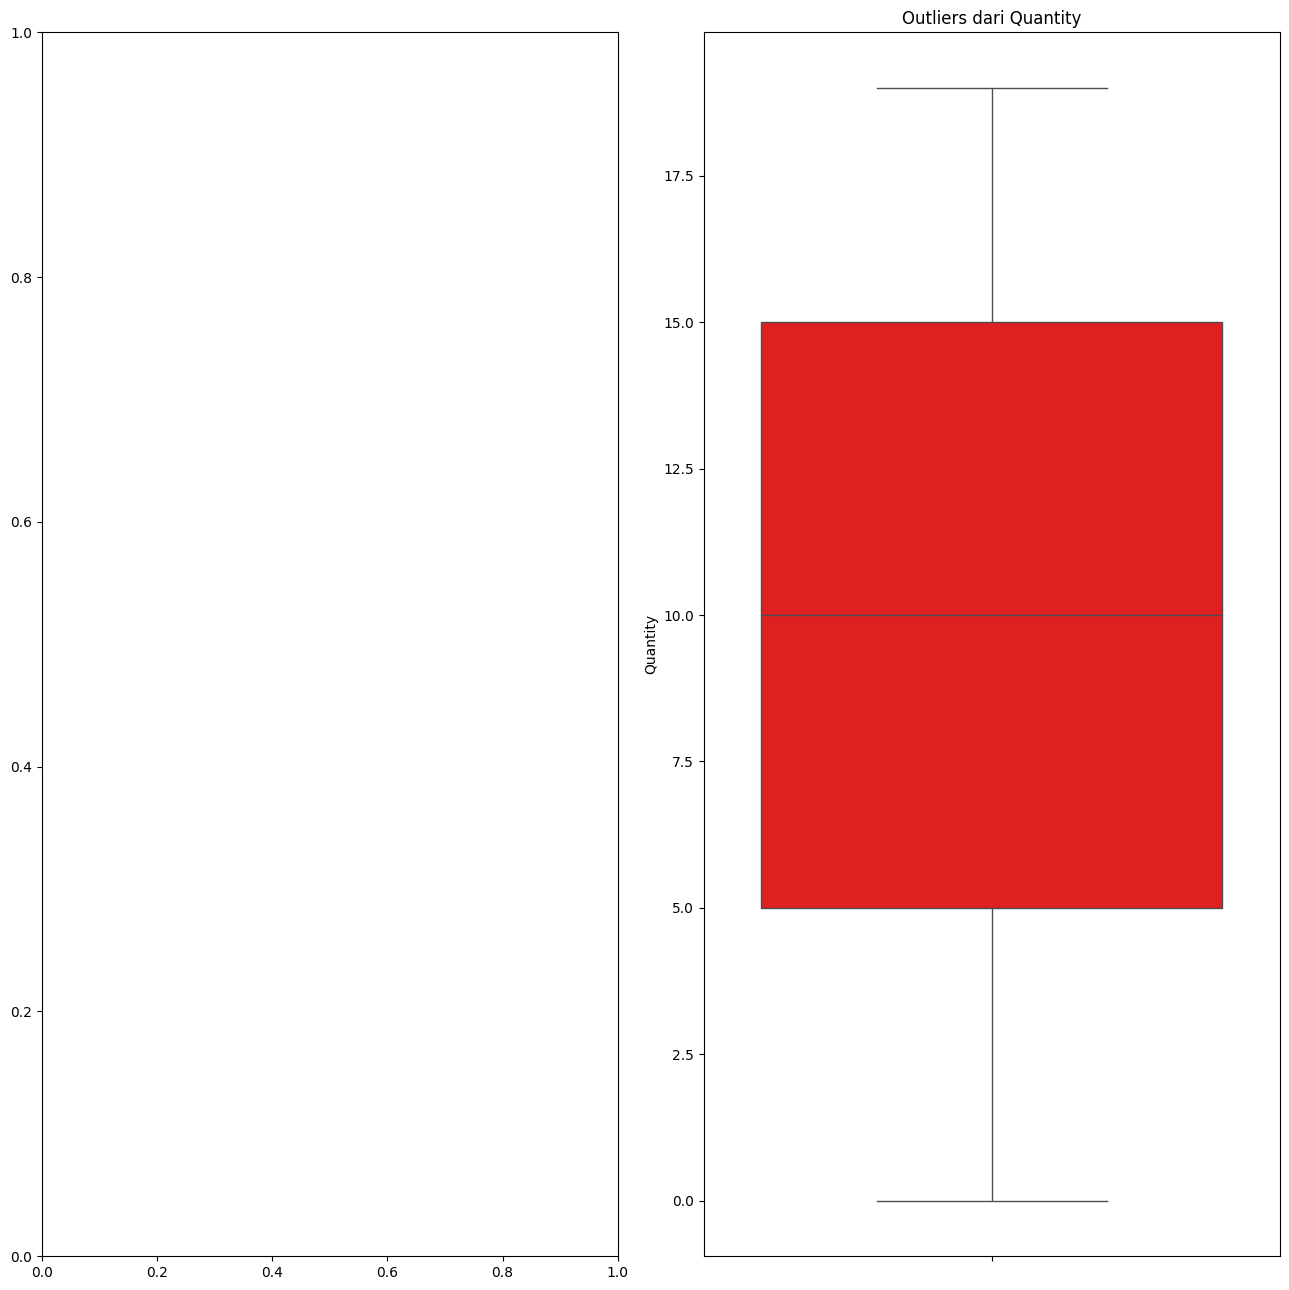

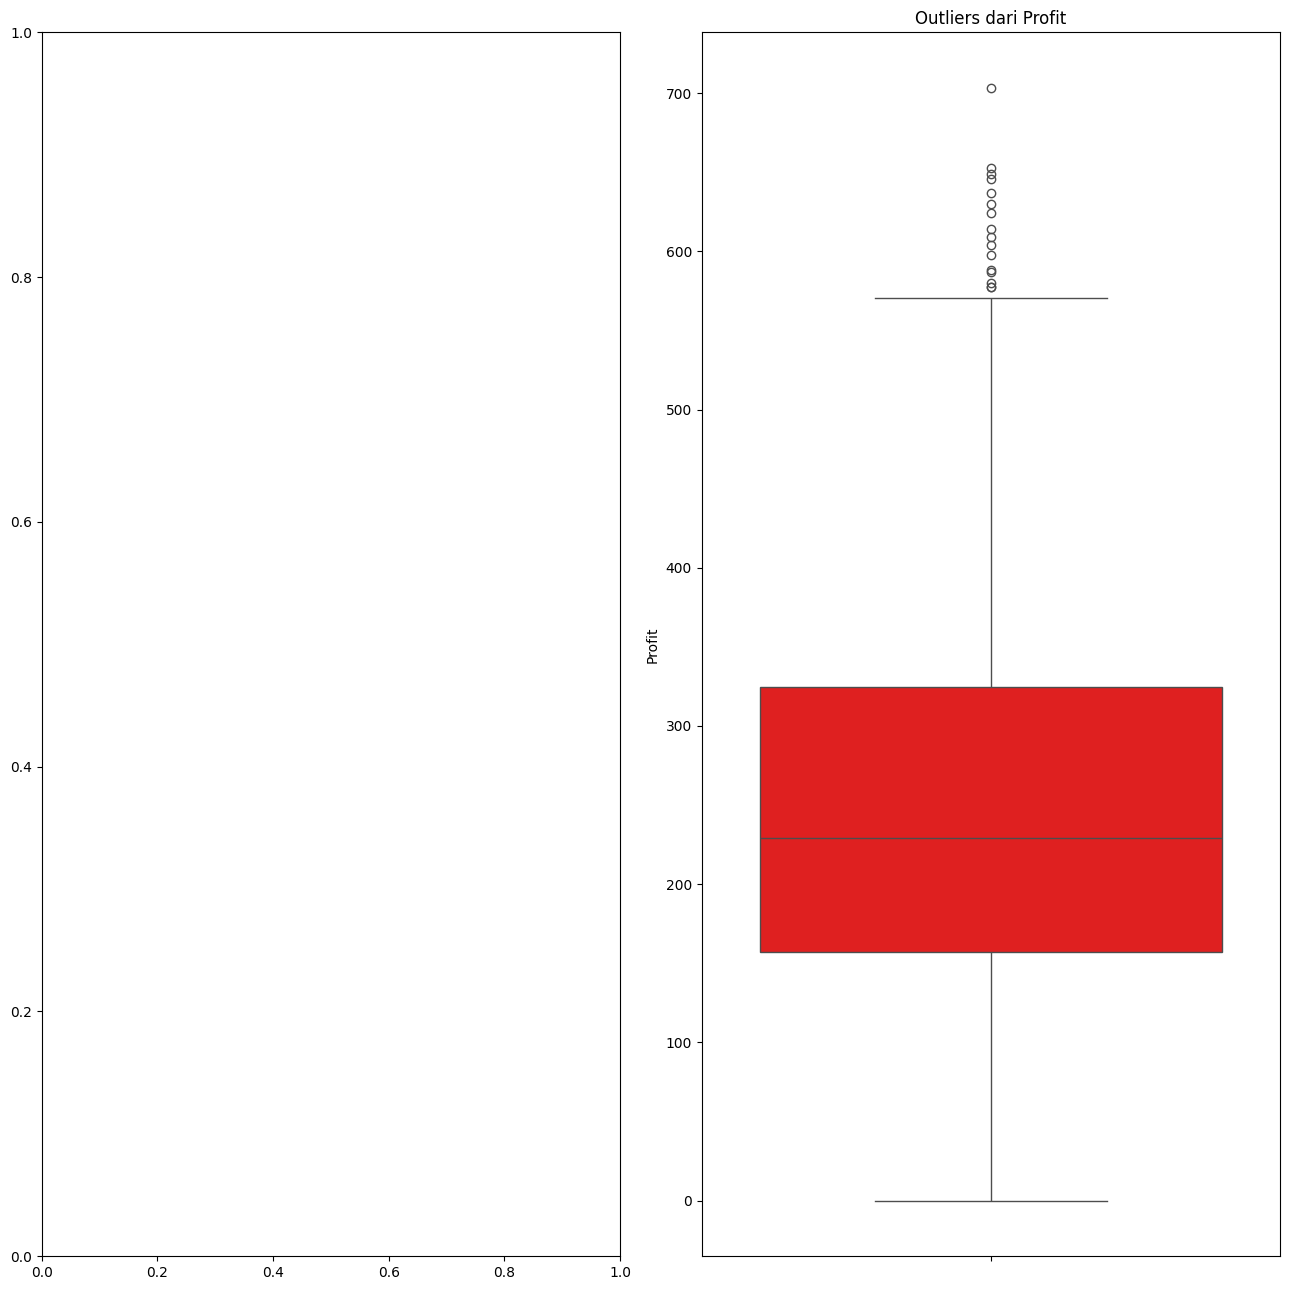

In [22]:
columns = df[['Quantity', 'Profit']]
for col in columns:
  fig, axes = plt.subplots(1, 2, figsize=(13,13))
#Outliers (Box Plot)
  sns.boxplot(df[col], ax=axes[1], color='red')
  axes[1].set_title(f'Outliers dari {col}')
  plt.tight_layout()

In [23]:
df.isnull().sum()

,0
Date,0
Category,4
Sales,2
Quantity,5
Profit,0
Region,5


### Imputing Missing Values in Numerical Columns with Median

I will fill the missing values in the `Sales` and `Quantity` columns using their median values, as these are numerical columns. For categorical columns (`Category` and `Region`), median imputation is not appropriate.

In [24]:
# Calculate the median for 'Sales' and 'Quantity' columns
median_sales = df['Sales'].median()
median_quantity = df['Quantity'].median()

# Fill missing values in 'Sales' and 'Quantity' with their medians
df['Sales'].fillna(median_sales, inplace=True)
df['Quantity'].fillna(median_quantity, inplace=True)

print(f"Missing values in 'Sales' filled with median: {median_sales}")
print(f"Missing values in 'Quantity' filled with median: {median_quantity}")

# Display the sum of null values again to confirm imputation
print("\nUpdated missing values after median imputation:")
display(df.isnull().sum())

Missing values in 'Sales' filled with median: 997.7251336236876
Missing values in 'Quantity' filled with median: 10.0

Updated missing values after median imputation:


/tmp/ipykernel_1088/3482738066.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(median_sales, inplace=True)
/tmp/ipykernel_1088/3482738066.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
Date,0
Category,4
Sales,0
Quantity,0
Profit,0
Region,5


# 5 Pertanyaan Analisis yang Dijawab dengan Data Manipulation:

1. Coba tunjukkan daftar transaksi dan barang mana saja yang profitnya paling rendah?

2. Rata-rata Profit berdasarkan Region?

3. Jumlah pembelian barang Minimum & maximum berdasarkan region?

4. Semua transaksi yang terjadi sebelum tanggal 1 Juni 2023?

In [25]:
# 1. Melihat kategori barang yang memiliki profit rendah, < 100.
df.loc[(df['Profit'] <= 100)].head()

,Date,Category,Sales,Quantity,Profit,Region
4,2023-01-01,NaN?,828.585950,12.0,88.591355,East
5,2023-01-02,Electronics,722.775149,10.0,82.396149,West
16,2023-01-04,Clothing,437.296968,8.0,44.454138,East
35,2023-01-08,Electronics,393.305520,17.0,69.290452,West
37,2023-01-08,Home Goods,497.948613,17.0,89.647832,South


In [28]:
# 2. Total Sales berdasarkan Region. Paling tinggi: West, Paling rendah: East.
df.groupby('Region')['Sales'].sum()

,Sales
Region,
East,394439.339642
Nan,1716.710787
North,449292.758063
South,469471.280583
West,470514.369828


In [30]:
# 3. Minimum & maximum of quantity based on region
df.groupby('Region')['Quantity'].agg(['min','max'])

,min,max
Region,,
East,1.0,19.0
Nan,8.0,8.0
North,1.0,19.0
South,1.0,19.0
West,0.0,19.0


In [29]:
# 4. Transaksi sebelum tanggal 1 Juni 2023
previous_transactions = df[df['Date'] < '1/6/2023']
previous_transactions

,Date,Category,Sales,Quantity,Profit,Region
0,2023-01-01,Electronics,1149.014246,11.0,383.664245,North
1,2023-01-01,Clothing,958.520710,7.0,224.054049,East
2,2023-01-01,Home Goods,1473.763845,2.0,466.593090,South
3,2023-01-01,Sports,1230.230419,6.0,123.310460,West
4,2023-01-01,NaN?,828.585950,12.0,88.591355,East
5,2023-01-02,Electronics,722.775149,10.0,82.396149,West
6,2023-01-02,Clothing,788.996859,15.0,225.271072,West
7,2023-01-02,Home Goods,358.113803,3.0,128.198339,East
8,2023-01-02,Sports,819.923845,2.0,250.298077,East
9,2023-01-02,Books,1284.231946,7.0,363.436353,West
